<a href="https://colab.research.google.com/github/sevdegulsahin/MedAI-Pneumonia-Detection/blob/main/MedAI_Pneumonia_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os

os.environ['KAGGLE_USERNAME'] = "sevdeglahin"
os.environ['KAGGLE_KEY'] = "KGAT_47df7027d92d3dba02100387ef4ba8ef"

print("⏳ Veri seti indiriliyor...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

print(" Dosyalar zipten çıkarılıyor... ")
!unzip -q chest-xray-pneumonia.zip

print("Veriler 'chest_xray' klasörüne hazır.")

⏳ Veri seti indiriliyor...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
 99% 2.27G/2.29G [00:45<00:00, 292MB/s]
100% 2.29G/2.29G [00:45<00:00, 53.6MB/s]
 Dosyalar zipten çıkarılıyor... 
Veriler 'chest_xray' klasörüne hazır.


Cihaz: cuda
Egitim Klasoru: chest_xray/chest_xray/train
Veriler hazirlaniyor...
Sinif Agirliklari -> Normal: 2.89 | Pneumonia: 1.0
V2.0 Egitim Basliyor...
Epoch [1/25] -> Loss: 0.5415 | Val Loss: 0.4424 | Acc: %89.75 | LR: 0.001
Epoch [2/25] -> Loss: 0.2271 | Val Loss: 0.8043 | Acc: %83.81 | LR: 0.001
Epoch [3/25] -> Loss: 0.1968 | Val Loss: 0.2385 | Acc: %94.25 | LR: 0.001
Epoch [4/25] -> Loss: 0.1757 | Val Loss: 0.1594 | Acc: %93.10 | LR: 0.001
Epoch [5/25] -> Loss: 0.1641 | Val Loss: 0.1433 | Acc: %93.49 | LR: 0.001
Epoch [6/25] -> Loss: 0.1444 | Val Loss: 0.2648 | Acc: %94.83 | LR: 0.001
Epoch [7/25] -> Loss: 0.1446 | Val Loss: 0.1362 | Acc: %96.26 | LR: 0.001
Epoch [8/25] -> Loss: 0.1261 | Val Loss: 0.1203 | Acc: %95.11 | LR: 0.001
Epoch [9/25] -> Loss: 0.1446 | Val Loss: 0.1183 | Acc: %94.54 | LR: 0.001
Epoch [10/25] -> Loss: 0.1338 | Val Loss: 0.1380 | Acc: %96.17 | LR: 0.001
Epoch [11/25] -> Loss: 0.1345 | Val Loss: 0.1105 | Acc: %95.98 | LR: 0.001
Epoch [12/25] -> Loss: 0.1392

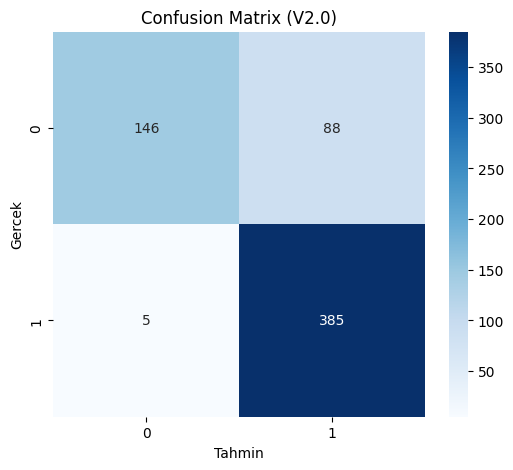

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import torch.nn.functional as F
import os
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. AYARLAR ---
BATCH_SIZE = 32
LEARNING_RATE = 0.001
EPOCHS = 25
PATIENCE = 5
IMG_SIZE = 128
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Cihaz: {DEVICE}")

# --- 2. KLASOR YOLLARI ---
train_dir = 'chest_xray/chest_xray/train'
test_dir = 'chest_xray/chest_xray/test'

if not os.path.exists(train_dir):
    train_dir = 'chest_xray/train'
    test_dir = 'chest_xray/test'

print(f"Egitim Klasoru: {train_dir}")

# --- 3. TRANSFORMLAR ---
train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    # Zoom islemi Affine icinde scale ile yapiliyor
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

val_test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# --- 4. VERI YUKLEME ---
print("Veriler hazirlaniyor...")
full_train_data = datasets.ImageFolder(root=train_dir, transform=train_transform)
targets = full_train_data.targets

# Dengeli Bolme
train_idx, val_idx = train_test_split(
    np.arange(len(targets)), test_size=0.2, shuffle=True, stratify=targets
)

train_dataset = Subset(full_train_data, train_idx)
val_dataset = Subset(full_train_data, val_idx)
test_dataset = datasets.ImageFolder(root=test_dir, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 5. SINIF AGIRLIKLARI ---
count_normal = targets.count(0)
count_pneumonia = targets.count(1)
weight_normal = count_pneumonia / count_normal
print(f"Sinif Agirliklari -> Normal: {weight_normal:.2f} | Pneumonia: 1.0")

class_weights = torch.tensor([weight_normal, 1.0]).to(DEVICE)

# --- 6. GELISMIS MODEL (V2.0) ---
class PneumoniaCNN_V2(nn.Module):
    def __init__(self):
        super(PneumoniaCNN_V2, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)

        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64, 128, 3, 1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128, 256, 3, 1)
        self.bn4 = nn.BatchNorm2d(256)

        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

model = PneumoniaCNN_V2().to(DEVICE)

# Loss ve Optimizer
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

# DUZELTME BURADA: verbose parametresi kaldirildi
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=2)

# --- 7. EGITIM DONGUSU ---
print("V2.0 Egitim Basliyor...")
best_val_loss = float('inf')
patience_counter = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    # Train
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    # Validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    avg_train_loss = running_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    # Scheduler
    scheduler.step(avg_val_loss)

    # Ekrana yazdırma kısmına Learning Rate bilgisini manuel ekleyelim
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch [{epoch+1}/{EPOCHS}] -> Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Acc: %{val_accuracy:.2f} | LR: {current_lr}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(model.state_dict(), 'best_pneumonia_model.pth')
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Erken Durdurma!")
            break

# --- 8. FINAL TEST ---
model.load_state_dict(best_model_wts)
print("\nFinal Test Raporu (Agirlikli Model)")

y_pred, y_true = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print(classification_report(y_true, y_pred, target_names=['NORMAL', 'PNEUMONIA']))

plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix (V2.0)')
plt.ylabel('Gercek')
plt.xlabel('Tahmin')
plt.show()

from google.colab import files
files.download('best_pneumonia_model.pth')

In [ ]:
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.cm as cm
import os
import shutil
import random
import sys

# --- 1. KONTROLLER ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "best_pneumonia_model.pth"

if not os.path.exists(MODEL_PATH):
    print("🚨 MODEL YOK! Lütfen 'best_pneumonia_model.pth' dosyasını yükleyiniz.")
    sys.exit()

# --- 2. MODEL MİMARİSİ ---
class PneumoniaCNN_V2(nn.Module):
    def __init__(self):
        super(PneumoniaCNN_V2, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, 1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, 1)
        self.bn4 = nn.BatchNorm2d(256)
        self.fc1 = nn.Linear(256 * 6 * 6, 512)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(512, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Modeli Yükle
model = PneumoniaCNN_V2()
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()

# --- 3. GRAD-CAM ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)
    def save_activation(self, module, input, output):
        self.activations = output
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
    def __call__(self, x, class_idx=None):
        output = self.model(x)
        if class_idx is None:
            class_idx = output.argmax(dim=1)
        self.model.zero_grad()
        score = output[0, class_idx]
        score.backward()
        gradients = self.gradients[0]
        activations = self.activations[0]
        weights = torch.mean(gradients, dim=(1, 2), keepdim=True)
        cam = torch.sum(weights * activations, dim=0)
        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-7)
        return cam.data.cpu().numpy()

grad_cam = GradCAM(model, model.conv4)

# --- 4. ÖRNEKLER ---
example_dir = "sunum_ornekleri"
if os.path.exists(example_dir): shutil.rmtree(example_dir)
os.makedirs(example_dir)
base_dir = "chest_xray/test" if os.path.exists("chest_xray/test") else "chest_xray/chest_xray/test"

if os.path.exists(base_dir):
    try:
        ns = random.sample(os.listdir(os.path.join(base_dir, "NORMAL")), 3)
        ps = random.sample(os.listdir(os.path.join(base_dir, "PNEUMONIA")), 3)
        for i, f in enumerate(ns): shutil.copy(os.path.join(base_dir, "NORMAL", f), f"{example_dir}/SAGLIKLI_{i+1}.jpeg")
        for i, f in enumerate(ps): shutil.copy(os.path.join(base_dir, "PNEUMONIA", f), f"{example_dir}/ZATURRE_{i+1}.jpeg")
    except: pass

# --- 5. TAHMİN ---
def predict_fn(image):
    if image is None: return None, "Resim Yok"
    orig_img = np.array(image.resize((224, 224)))
    if len(orig_img.shape) == 2: orig_img = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2RGB)

    transform = transforms.Compose([transforms.Grayscale(1), transforms.Resize((128, 128)), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
    inp = transform(image).unsqueeze(0).to(DEVICE)
    out = model(inp)
    probs = F.softmax(out, dim=1)[0]
    pred_idx = probs.argmax().item()

    heatmap = grad_cam(inp, class_idx=pred_idx)
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * cm.jet(heatmap)[:, :, :3])
    overlay = cv2.addWeighted(orig_img, 0.6, heatmap, 0.4, 0)
    return overlay, {"NORMAL": float(probs[0]), "PNEUMONIA": float(probs[1])}

# --- 6. ARAYÜZ (RENK GARANTİLİ) ---

# CSS İle Renkleri Zorla Ayarlıyoruz
# Background: Koyu Lacivert (#0f172a)
# Yazılar: Beyaz (#ffffff)
custom_css = """
body, .gradio-container {background-color: #0f172a !important; color: white !important;}
h1, h2, h3, h4, span, p, label {color: white !important;}
.block {background-color: #1e293b !important; border: 1px solid #334155 !important;}
"""

with gr.Blocks(css=custom_css, title="Med-AI") as demo:

    # Başlık Alanı
    with gr.Row():
        gr.Markdown(
            """
            <div style="text-align: center;">
                <h1 style="color: #60a5fa; font-size: 2.5rem; margin-bottom: 0;">🩺 Med-AI V2.0</h1>
                <h3 style="color: white; margin-top: 5px;">Yapay Zeka Destekli Radyoloji Asistanı</h3>
            </div>
            """
        )

    # Ana Gövde
    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="📸 Röntgen Yükle", height=320)
            analyze_btn = gr.Button("🔍 ANALİZ ET", variant="primary") # Mavi buton

        with gr.Column():
            output_img = gr.Image(label="🔥 Analiz Sonucu", height=320)
            output_lbl = gr.Label(label="Teşhis", num_top_classes=2)

    analyze_btn.click(fn=predict_fn, inputs=input_img, outputs=[output_img, output_lbl])

    # Örnekler
    if os.path.exists(example_dir):
        gr.Markdown("### 👇 Test Örnekleri (Resimlerin altındaki isme bakınız)")
        gr.Examples(
            examples=[[f"{example_dir}/{f}"] for f in sorted(os.listdir(example_dir))],
            inputs=input_img,
            outputs=[output_img, output_lbl],
            fn=predict_fn,
            cache_examples=True,
        )

print("🚀 Arayüz Hazır! Linke tıklayabilirsiniz.")
demo.launch(share=True, debug=True)

🚨 MODEL YOK! Lütfen 'best_pneumonia_model.pth' dosyasını yükleyiniz.


SystemExit: 

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [13]:
import gradio as gr
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2
import matplotlib.cm as cm
import os
import shutil
import random
import sys

# --- 1. MODEL AYARLARI ---
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "best_pneumonia_model.pth"

if not os.path.exists(MODEL_PATH):
    print("HATA: Model dosyasi yok! Lutfen 'best_pneumonia_model.pth' dosyasini yukleyin.")
    sys.exit()

class PneumoniaCNN_V2(nn.Module):
    def __init__(self):
        super(PneumoniaCNN_V2, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1); self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, 1); self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, 1); self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, 3, 1); self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(256 * 6 * 6, 512); self.fc2 = nn.Linear(512, 2)
        self.dropout = nn.Dropout(0.5)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

print("Model Yukleniyor...")
model = PneumoniaCNN_V2()
model.load_state_dict(torch.load(MODEL_PATH, map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Model Hazir!")

# --- 2. GRAD-CAM ---
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model; self.target_layer = target_layer
        self.grads = None; self.acts = None
        target_layer.register_forward_hook(self.save_act)
        target_layer.register_full_backward_hook(self.save_grad)
    def save_act(self, m, i, o): self.acts = o
    def save_grad(self, m, gi, go): self.grads = go[0]
    def __call__(self, x, idx=None):
        out = self.model(x)
        if idx is None: idx = out.argmax(dim=1)
        self.model.zero_grad()
        out[0, idx].backward()
        w = torch.mean(self.grads[0], dim=(1,2), keepdim=True)
        cam = F.relu(torch.sum(w * self.acts[0], dim=0))
        cam = cam - cam.min(); cam = cam / (cam.max() + 1e-7)
        return cam.data.cpu().numpy()

grad_cam = GradCAM(model, model.conv4)

# --- 3. GALERI VERILERINI HAZIRLA ---
example_dir = "sunum_ornekleri"
if os.path.exists(example_dir): shutil.rmtree(example_dir)
os.makedirs(example_dir)

base_dir = "chest_xray/chest_xray/test"
if not os.path.exists(base_dir): base_dir = "chest_xray/test"

gallery_data = []
answer_key_list = []

if os.path.exists(base_dir):
    try:
        ns = random.sample(os.listdir(os.path.join(base_dir, "NORMAL")), 3)
        ps = random.sample(os.listdir(os.path.join(base_dir, "PNEUMONIA")), 3)

        temp_list = []
        for f in ns: temp_list.append((f, "NORMAL", "SAGLIKLI"))
        for f in ps: temp_list.append((f, "PNEUMONIA", "ZATURRE"))
        random.shuffle(temp_list)

        for i, (fname, folder, label_tr) in enumerate(temp_list):
            src = os.path.join(base_dir, folder, fname)
            dst_name = f"Ornek_{i+1}.jpeg"
            dst = f"{example_dir}/{dst_name}"
            shutil.copy(src, dst)

            # Galeri Gorunumu
            gallery_data.append((dst, f"Ornek {i+1}"))

            # Cevap Anahtari Metni
            answer_key_list.append(f"Ornek {i+1} Secildi -> GERCEK DURUM: {label_tr}")

    except: pass

# --- 4. TAHMIN FONKSIYONU ---
def predict_fn(image):
    if image is None: return None, "Resim Yok", ""

    orig_img = np.array(image.resize((224, 224)))
    if len(orig_img.shape) == 2: orig_img = cv2.cvtColor(orig_img, cv2.COLOR_GRAY2RGB)

    t = transforms.Compose([transforms.Grayscale(1), transforms.Resize((128, 128)), transforms.ToTensor(), transforms.Normalize([0.5], [0.5])])
    inp = t(image).unsqueeze(0).to(DEVICE)
    out = model(inp); probs = F.softmax(out, dim=1)[0]

    heatmap = cv2.resize(grad_cam(inp, probs.argmax().item()), (224, 224))
    heatmap = np.uint8(255 * cm.jet(heatmap)[:, :, :3])
    overlay = cv2.addWeighted(orig_img, 0.6, heatmap, 0.4, 0)

    # Emojisiz metinler
    return overlay, {"SAĞLIKLI (Normal)": float(probs[0]), "ZATÜRRE (Pneumonia)": float(probs[1])}

# Galeri Secim Fonksiyonu
def on_gallery_select(evt: gr.SelectData):
    selected_index = evt.index
    img_path = gallery_data[selected_index][0]
    true_answer = answer_key_list[selected_index]
    return Image.open(img_path), true_answer

# --- 5. ARAYUZ ---
css = """
body, .gradio-container {background-color: #0f172a !important; color: white !important;}
h1, h2, h3, h4, span, p, label {color: white !important;}
.block {background-color: #1e293b !important; border: 1px solid #334155 !important;}
.grid-wrap.fixed-height .grid-container button.selected {
    border: 4px solid #f97316 !important;
    transform: scale(0.96);
    opacity: 1 !important;
}
"""

with gr.Blocks(css=css, title="Med-AI") as demo:
    gr.Markdown(
        """
        <div style="text-align: center;">
            <h1 style="color: #60a5fa !important;">Med-AI V2.0</h1>
            <h3 style="color: white !important;">Zaturre Teshis Paneli</h3>
        </div>
        """
    )

    with gr.Row():
        with gr.Column():
            input_img = gr.Image(type="pil", label="Secilen Rontgen", height=320)
            true_label_box = gr.Textbox(label="CEVAP ANAHTARI", interactive=False, placeholder="Asagidan bir ornek seciniz...")
            btn = gr.Button("ANALIZ ET", variant="primary")

        with gr.Column():
            out_img = gr.Image(label="Odak Haritasi", height=320)
            out_lbl = gr.Label(label="Yapay Zeka Tahmini")

    btn.click(predict_fn, input_img, [out_img, out_lbl])

    if gallery_data:
        gr.Markdown("### Test Ornekleri (Birini secin, cercevesi kalacaktir)")
        gallery = gr.Gallery(
            label="Test Veri Seti",
            value=gallery_data,
            columns=6,
            height=200,
            allow_preview=False,
            show_label=False
        )
        gallery.select(fn=on_gallery_select, inputs=None, outputs=[input_img, true_label_box])

print("Arayuz Baslatiliyor... Linke Tikla!")
demo.launch(share=True, debug=True)

Model Yukleniyor...
Model Hazir!


/tmp/ipython-input-416354556.py:144: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=css, title="Med-AI") as demo:


Arayuz Baslatiliyor... Linke Tikla!
Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://d2e50a3e43df28ac63.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://d2e50a3e43df28ac63.gradio.live
